# Students Test Score: Extended Dataset Starter Notebook
---
---
This is a starter notebook to get you started with the dataset ([Student Test Scores: Extended Dataset](https://www.kaggle.com/datasets/desalegngeb/students-exam-scores)). Within this dataset there are two csv files (`Original_data_with_more_rows.csv` and `Expanded_data_with_more_features.csv`)

- `Original_data_with_more_rows.csv`: This file has more than 30641 rows and 8 columns. And has no missing values.
- `Expanded_data_with_more_features.csv`: This file, just like the above one, has 30641 rows, but with more features (14 columns) and has missing values in it which makes it ideal for data preprocessing such as missing value imputation techniques.

**Note**: There exists a similar (in part, identical) kaggle dataset which is a smaller (1k rows instead of >30641) version of the `Original_data_with_more_rows.csv` data on which I have already done extensive EDA and predictions. If you are interested you may check it here, [Student's Test Performance: EDA and Prediction](https://www.kaggle.com/code/desalegngeb/student-s-test-performance-eda-and-prediction)

---

**Changelogs**:

- In v1 this notebook was titled: "Students Test Score: Extended Dataset"
- For the rest check the `compare versions`

---
---

### Data dictionary

The following are the column descriptions. Columns 0 to 5 and 11 to 13 are common to both files. The rest are present to the extended file only.

0.   **Gender**: gender of the student (male/female)                
1.   **EthnicGroup**: ethnic group of the student (group A to E)           
2.   **ParentEduc**: parent(s) education background            
3.   **LunchType**: school luch type (standard or free/reduced)            
4.   **TestPrep**: test preparation course (completed or none)             
5.   **ParentMaritalStatus**: parent(s) marital status  
6.   **PracticeSport**: how often the student parctice sport         
7.   **IsFirstChild**: if the child is first child in the family or not         
8.   **NrSiblings** : Number of siblings the student has           
9.   **TransportMeans**: Means of transport to school        
10.  **WklyStudyHours**: Weekly self-study hours        
11.  **MathScore**: math test score              
12.  **ReadingScore**: reading test score          
13.  **WritingScore**  writing test score
---

## Project Overview
This project analyzes how study habits and preparation influence students’ academic performance using statistical methods and visualizations.

In [187]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
import missingno as msno
%matplotlib inline

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [188]:
data_extended = pd.read_csv('Expanded_data_with_more_features.csv')
data_org = pd.read_csv('Original_data_with_more_rows.csv')

## 1. Original dataset

In [189]:
data_org = data_org.drop('Unnamed: 0', axis=1)
data_org.head(3)

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,MathScore,ReadingScore,WritingScore
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93


In [190]:
data_org.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Gender        30641 non-null  object
 1   EthnicGroup   30641 non-null  object
 2   ParentEduc    30641 non-null  object
 3   LunchType     30641 non-null  object
 4   TestPrep      30641 non-null  object
 5   MathScore     30641 non-null  int64 
 6   ReadingScore  30641 non-null  int64 
 7   WritingScore  30641 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 1.9+ MB


### Check for duplicates
- There are no duplicate values in this dataset.

In [191]:
data_org.duplicated().sum()

np.int64(0)

### Check for null values
- No null values are present - no impuatation is need.

In [192]:
data_org.isna().sum().sum()

np.int64(0)

### Test score distributions

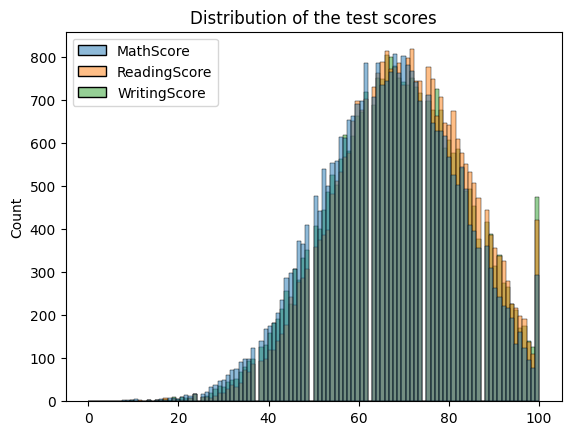

In [193]:
sns.histplot(data_org[['MathScore', 'ReadingScore', 'WritingScore']])
plt.title('Distribution of the test scores');

### Analysis of Test Score Distributions

The distribution shows that Math, Reading, and Writing scores are concentrated around the mid-to-high range, with most students scoring between approximately 50 and 85.

This suggests that the majority of students perform at an average or above-average level, with fewer students at the extreme low or high ends.

It can also be observed that the three score distributions are quite similar in shape, indicating consistency across different subjects.

However, slight differences suggest that some subjects may be slightly easier or that students perform differently depending on the skill required.

Overall, this indicates that student performance is relatively balanced across subjects, and most students cluster around moderate achievement levels rather than extreme outcomes.


In [194]:
data_org.groupby(['Gender'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)

/tmp/ipykernel_4626/3377482359.py:1: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data_org.groupby(['Gender'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)


,MathScore,ReadingScore,WritingScore
Gender,,,
female,64.262902,73.093815,72.897692
male,69.269633,66.108957,63.978708


## 2. Extended Dataset

As mensioned in the intriduction section of the notebooks, this data is the extended version of the original dataset.
It has more features and also null values. This is a good dataset for those who would like to practice on their data preprocessing skils.

The additional features are :
- PracticeSport, IsFirstChild, TranspotMeans and WklyStudyHours

In [195]:
data_extended = data_extended.drop('Unnamed: 0', axis=1)
data_extended.head(3)

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91


In [196]:
data_extended.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               30641 non-null  object 
 1   EthnicGroup          28801 non-null  object 
 2   ParentEduc           28796 non-null  object 
 3   LunchType            30641 non-null  object 
 4   TestPrep             28811 non-null  object 
 5   ParentMaritalStatus  29451 non-null  object 
 6   PracticeSport        30010 non-null  object 
 7   IsFirstChild         29737 non-null  object 
 8   NrSiblings           29069 non-null  float64
 9   TransportMeans       27507 non-null  object 
 10  WklyStudyHours       29686 non-null  object 
 11  MathScore            30641 non-null  int64  
 12  ReadingScore         30641 non-null  int64  
 13  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(3), object(10)
memory usage: 3.3+ MB


### Correcting data type

We see that `NrSiblings` has wrong datatype (`float64`) instead of `int`. Let's change that.

In [197]:
data_extended['NrSiblings'] = data_extended['NrSiblings'].astype(pd.Int64Dtype())
data_extended['NrSiblings'].dtypes

Int64Dtype()

### Check for duplicates
- There are no duplicates.

In [198]:
data_extended.duplicated().sum()

np.int64(0)

### Check for null values
- There are only FOUR columns which do not have missing values. The rest have null values ranging from 2.1% up to 10%. So missing value imputation is needed.

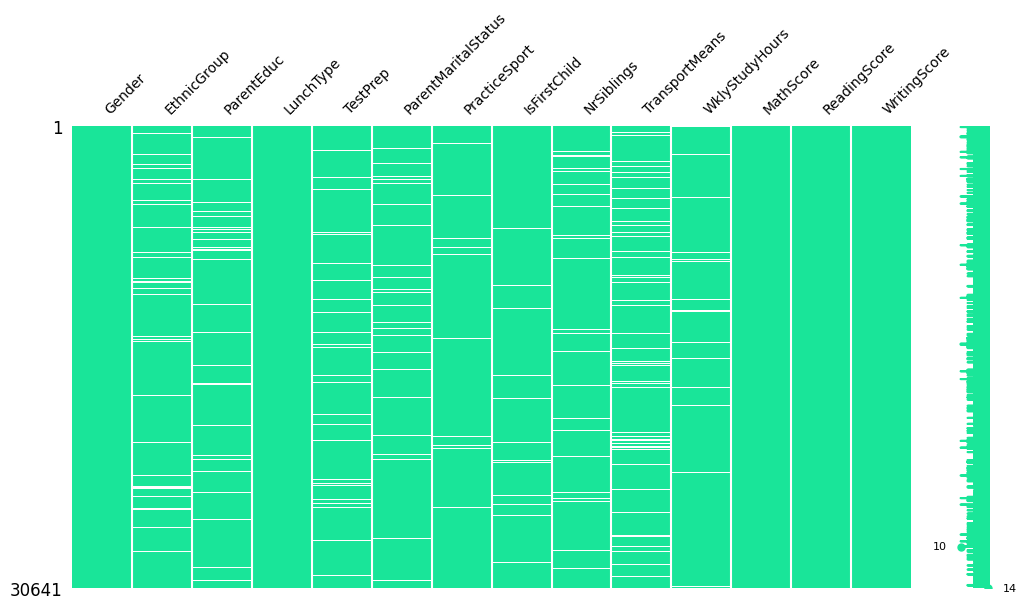

In [199]:
msno.matrix(data_extended,
           figsize=(12, 6),
           color=(0.1, 0.9, 0.6),
           fontsize=10);

### Analysis of Missing Data

The visualization shows that most variables in the dataset are complete, with very few missing values observed across different features.

This suggests that the dataset is generally well-structured and suitable for analysis without requiring extensive data cleaning.

However, the presence of some missing values indicates that minor preprocessing steps, such as imputation, may be necessary.

Overall, this indicates that missing data is not a major issue in this dataset and is unlikely to significantly affect the analysis results.

In [200]:
for col in data_extended.columns:
    print('Missing values in column {} is {} %'.format(col, np.round(data_extended[col].isnull().sum()*100/(len(data_extended[col])), 1)))

Missing values in column Gender is 0.0 %
Missing values in column EthnicGroup is 6.0 %
Missing values in column ParentEduc is 6.0 %
Missing values in column LunchType is 0.0 %
Missing values in column TestPrep is 6.0 %
Missing values in column ParentMaritalStatus is 3.9 %
Missing values in column PracticeSport is 2.1 %
Missing values in column IsFirstChild is 3.0 %
Missing values in column NrSiblings is 5.1 %
Missing values in column TransportMeans is 10.2 %
Missing values in column WklyStudyHours is 3.1 %
Missing values in column MathScore is 0.0 %
Missing values in column ReadingScore is 0.0 %
Missing values in column WritingScore is 0.0 %


### Imputing null values
- There are several available option to fill the null values. Here we use the most frequent values in each column to fill the na's.

In [201]:
data_extended = data_extended.apply(lambda x: x.fillna(x.value_counts().index[0]))
null_val = data_extended.isna().sum().sum()

if null_val > 0:
    print('Try imputing again, there are {} null values remaining in the dataset'.format(null_val))
else:
    print('Congratulations! You have successfully imputed all the null values in the dataset.')

Congratulations! You have successfully imputed all the null values in the dataset.


### Test score distributions

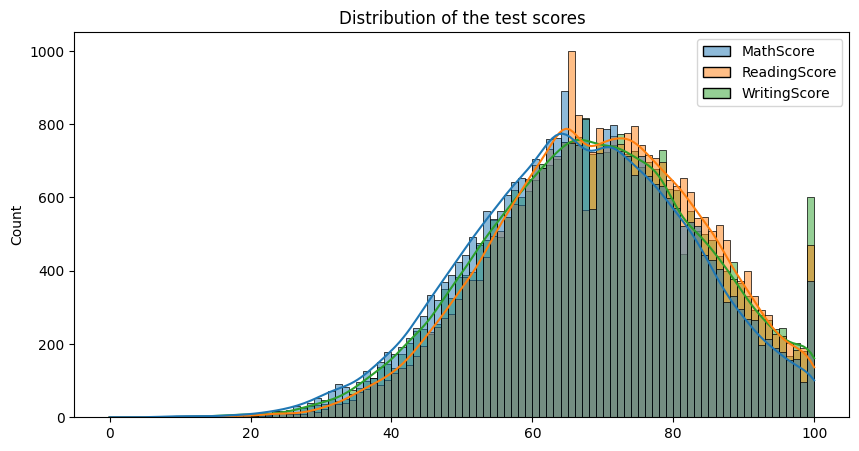

In [202]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data_extended[['MathScore', 'ReadingScore', 'WritingScore']], bins=100,  kde=True)
plt.title('Distribution of the test scores');

### Analysis After Handling Missing Values

The distribution shows that after handling missing values, the overall shape of Math, Reading, and Writing scores remains consistent and centered around the mid-to-high range.

This suggests that the imputation process did not significantly distort the underlying distribution of the data.

It can also be observed that the distributions appear smoother, which indicates improved data completeness and stability.

However, small variations still exist between subjects, suggesting that performance differences across subjects are preserved even after preprocessing.

Overall, this indicates that the data cleaning process was effective and maintained the integrity of the dataset while preparing it for further analysis.

In [203]:
def display_stats(df, col):
    '''
    Given a dataFrame and the column name, this function calculates and returns two stats summary dataframes.
    - A normalized value_counts of the categories in the given columns "col" and
    - A sorted mean of the three test scores grouped by the categories in column "col"
    '''

    val_cnt = df[col].value_counts().to_frame(name=col + ' (count)')
    val_cnt_norm = df[col].value_counts(normalize=True).mul(100).to_frame(name=col + ' (%)')

    val_cnt_table = pd.concat([val_cnt, val_cnt_norm], axis=1)

    mean_score_summary = df.groupby([col])[['MathScore', 'ReadingScore', 'WritingScore']]\
    .agg(np.mean).sort_values(by='MathScore', ascending=False)

    return display(val_cnt_table, mean_score_summary)


In [204]:
data_extended[['MathScore', 'ReadingScore', 'WritingScore']].agg([np.mean, np.std, np.max, np.min])

/tmp/ipykernel_4626/4130991671.py:1: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using Series.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data_extended[['MathScore', 'ReadingScore', 'WritingScore']].agg([np.mean, np.std, np.max, np.min])
/tmp/ipykernel_4626/4130991671.py:1: FutureWarning: The provided callable <function std at 0x7929901f9a80> is currently using Series.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  data_extended[['MathScore', 'ReadingScore', 'WritingScore']].agg([np.mean, np.std, np.max, np.min])
/tmp/ipykernel_4626/4130991671.py:1: FutureWarning: The provided callable <function max at 0x7929901f8f40> is currently using Series.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the strin

,MathScore,ReadingScore,WritingScore
mean,66.558402,69.377533,68.418622
std,15.361616,14.758952,15.443525
max,100.000000,100.000000,100.000000
min,0.000000,10.000000,4.000000


### Gender
- The distribution of male and female students in the dataset is fairly balanced.
- Score wise girls performed better that boys in `ReadingScore` and`writingScore`, whereas boys scored better in `MathScore`.

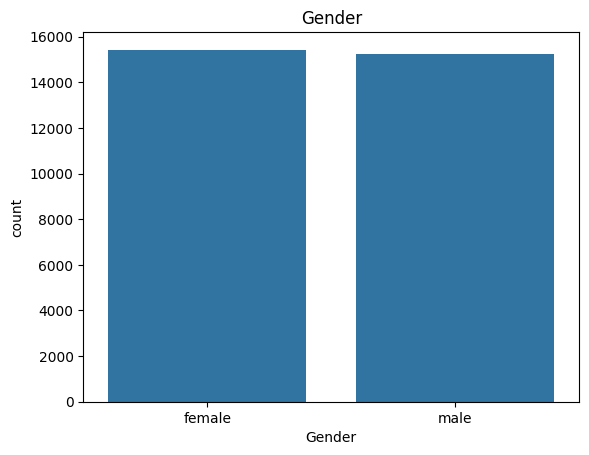

In [205]:
sns.countplot(x=data_extended['Gender'])
plt.title('Gender');

### Analysis of Gender Distribution

The visualization shows that the number of female and male students in the dataset is nearly balanced.

This suggests that the dataset does not suffer from a gender imbalance, which is important for making fair comparisons between groups.

Because both groups are similarly represented, any observed differences in performance are less likely to be caused by sample size bias.

Overall, this indicates that gender-based comparisons in the analysis are reliable and not significantly affected by unequal representation.

In [206]:
data_extended.groupby(['Gender'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)

/tmp/ipykernel_4626/3237833266.py:1: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data_extended.groupby(['Gender'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)


,MathScore,ReadingScore,WritingScore
Gender,,,
female,64.080654,72.853216,72.856457
male,69.069856,65.854571,63.920418


### Parent(s) educational background


- There are six categories of educational background of parent(s) of the students, ranging from master's education (the highest level) to highschool dropouts (some high school)
- In terms of distribution, `master's degree` holder parent(s) are the least at 7% and parent(s) with `some college` are the most at 23%.
- When it comes to the students' test scores, there seems to be a clear correlation with their parents(s) educational background. Children of highly educated parents score better than the children of less educated parents. This pattern is seen consistently with all three test subjects.


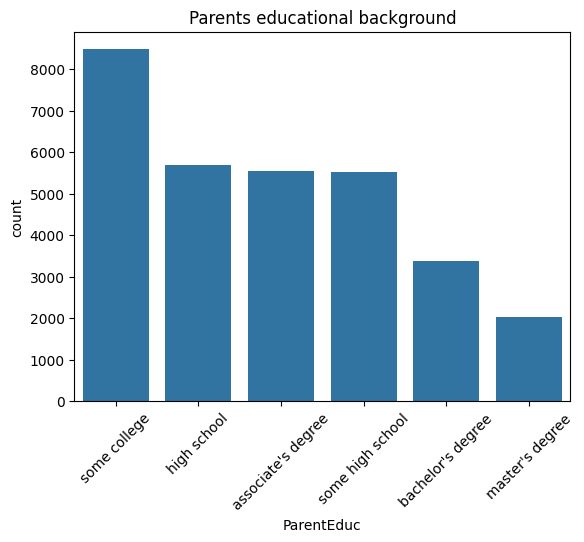

In [207]:
sns.countplot(x=data_extended['ParentEduc'], \
              order=['some college', 'high school', "associate's degree", 'some high school', "bachelor's degree", "master's degree"])
plt.title('Parents educational background')
plt.xticks(rotation=45);

### Analysis of Parental Education Distribution

The visualization shows that most students come from families where parents have some college or high school education, while fewer students have parents with bachelor's or master's degrees.

This suggests that the dataset is more heavily represented by middle education levels rather than highly educated backgrounds.

However, all education levels are still present, which allows for meaningful comparisons across different parental education groups.

Overall, this indicates that parental education varies across the dataset, providing a useful basis for analyzing its potential impact on student performance.

In [208]:
display_stats(data_extended, 'ParentEduc')

/tmp/ipykernel_4626/2462480265.py:14: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  .agg(np.mean).sort_values(by='MathScore', ascending=False)


,ParentEduc (count),ParentEduc (%)
ParentEduc,,
some college,8478,27.668810
high school,5687,18.560099
associate's degree,5550,18.112986
some high school,5517,18.005287
bachelor's degree,3386,11.050553
master's degree,2023,6.602265


,MathScore,ReadingScore,WritingScore
ParentEduc,,,
master's degree,72.336134,75.832921,76.356896
bachelor's degree,70.466627,73.062020,73.331069
associate's degree,68.365586,71.124324,70.299099
some college,66.445978,69.189667,68.456711
high school,64.435731,67.213997,65.421136
some high school,62.584013,65.510785,63.632409


### Ethnic group
- There are five races/ethnic groups represented in the dataset; (anonymized) from `group A` to `group E`
- With ~32% of the student population, race group C  are the most represented whereas with only ~8% race  group A are the least.
- The effect of race on students' performance is clear to see. Race group E students are by far the better performers having scored 7-points more than the second group (D) in math and 4 more points in reading score and close to 2 points in writing test. At the other end of the scoreboard we find race group A; this group scored more than 12-points on math lower than that of group E!

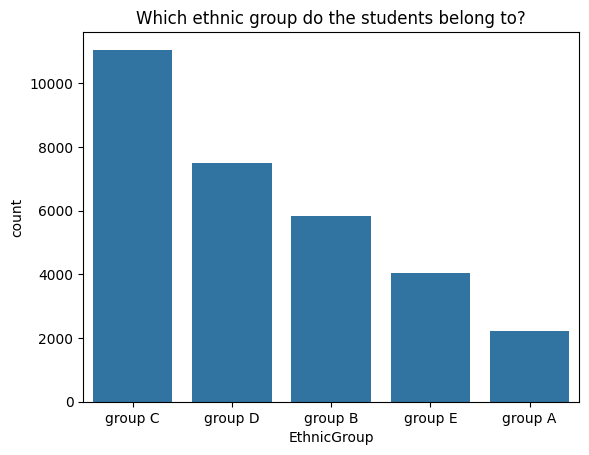

In [209]:
sns.countplot(x=data_extended['EthnicGroup'], \
              order=['group C', 'group D', 'group B', 'group E', 'group A'])
plt.title('Which ethnic group do the students belong to?');

### Analysis of Ethnic Group Distribution

The visualization shows that the majority of students belong to group C, followed by groups D and B, while groups E and A have fewer students.

This suggests that the dataset is not evenly distributed across ethnic groups, with some groups being more represented than others.

However, all groups are still included in the dataset, allowing for comparisons between them.

Overall, this indicates that while ethnic diversity exists in the dataset, the imbalance in group sizes should be considered when interpreting any group-based performance differences.

In [210]:
display_stats(data_extended,'EthnicGroup')

/tmp/ipykernel_4626/2462480265.py:14: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  .agg(np.mean).sort_values(by='MathScore', ascending=False)


,EthnicGroup (count),EthnicGroup (%)
EthnicGroup,,
group C,11052,36.069319
group D,7503,24.486799
group B,5826,19.013740
group E,4041,13.188212
group A,2219,7.241931


,MathScore,ReadingScore,WritingScore
EthnicGroup,,,
group E,75.298936,74.251423,72.677060
group D,67.666400,70.382247,70.890844
group C,64.943811,68.517734,67.149294
group B,63.490216,67.320460,65.895125
group A,62.991888,66.787742,65.251915


### Lunch type
- There are two types of luches students can have at school, standard or reduced(free) lunch.
- Almost 65% of the students have the standard option.
- The ratio of standard to free luch seems failrly consistent between race group.
- It appears that lunch type has a paramount effect on test scores. On math test score the difference between starndard and free lunch is almost 12 points. In wrtiting and reading tests the difference is 8 and 9 respectively.  

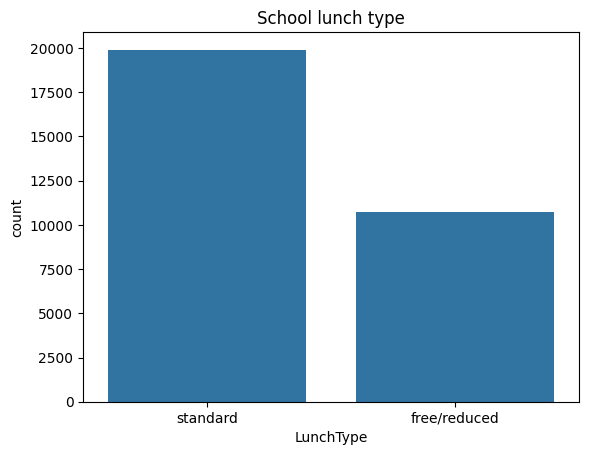

In [211]:
sns.countplot(x=data_extended['LunchType'])
plt.title('School lunch type');

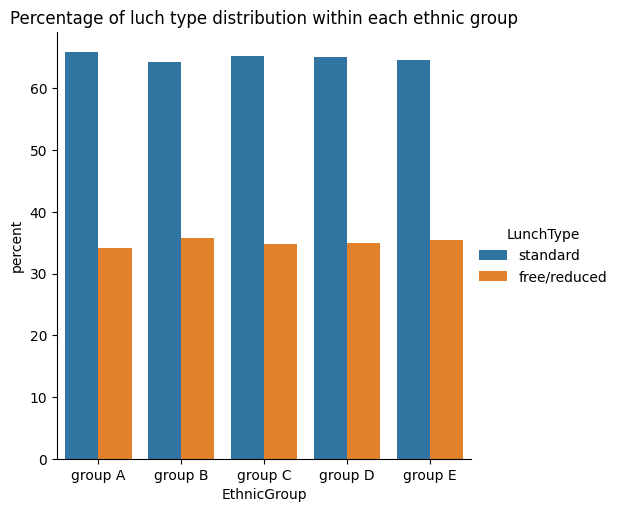

In [212]:
# fig, ax = plt.subplots(figsize=(10, 5))
x, y = 'EthnicGroup', 'LunchType'
data_extended.groupby(x)[y].value_counts(normalize=True).mul(100).rename('percent').reset_index()\
.pipe((sns.catplot,'data'), x=x,y='percent',hue=y,kind='bar')
plt.title('Percentage of luch type distribution within each ethnic group');

In [213]:
display_stats(data_extended, 'LunchType')

/tmp/ipykernel_4626/2462480265.py:14: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  .agg(np.mean).sort_values(by='MathScore', ascending=False)


,LunchType (count),LunchType (%)
LunchType,,
standard,19905,64.961979
free/reduced,10736,35.038021


,MathScore,ReadingScore,WritingScore
LunchType,,,
standard,70.709370,72.175634,71.529716
free/reduced,58.862332,64.189735,62.650522


### Analysis of Lunch Type Across Ethnic Groups

Most students in all ethnic groups have a standard lunch, while a smaller portion receive free or reduced lunch.

This indicates that lunch type distribution is fairly similar across groups, with only minor differences.

Overall, lunch type does not vary significantly by ethnic group and is unlikely to fully explain performance differences.

### Weekly study hours

- This feature is a weekly study hours the students had been studying after school. There are three distinct values less that 5hrs a week, between 5 -10hrs per week and more than 10hrs per week.
- More than half (56%) of the students study between 5 - 10 hrs. However, only 17% used more than 10 hrs weekly study hours.
- Test score result shows that performance is direclty related to the hours spent studying.

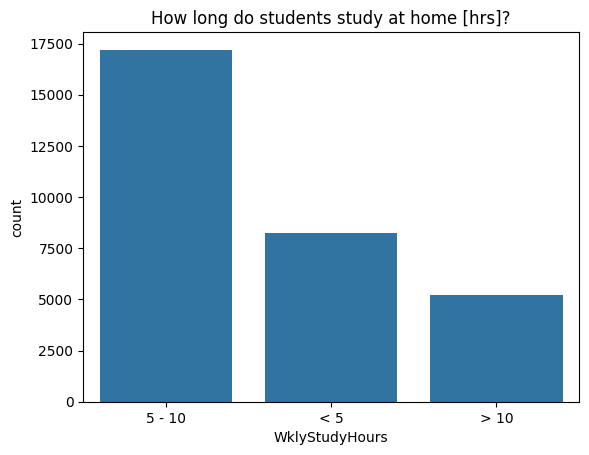

In [214]:
sns.countplot(x=data_extended['WklyStudyHours'], \
             order=['5 - 10', '< 5', '> 10'])
plt.title('How long do students study at home [hrs]?');

In [215]:
display_stats(data_extended, 'WklyStudyHours')

/tmp/ipykernel_4626/2462480265.py:14: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  .agg(np.mean).sort_values(by='MathScore', ascending=False)


,WklyStudyHours (count),WklyStudyHours (%)
WklyStudyHours,,
5 - 10,17201,56.137202
< 5,8238,26.885546
> 10,5202,16.977253


,MathScore,ReadingScore,WritingScore
WklyStudyHours,,,
> 10,68.696655,70.365436,69.777778
5 - 10,66.859078,69.654148,68.643800
< 5,64.580359,68.176135,67.090192


### Analysis of Weekly Study Hours

Most students study between 5–10 hours per week, while fewer students study less than 5 hours or more than 10 hours.

This suggests that moderate study time is the most common behavior among students.

However, the smaller group of students studying more than 10 hours may represent high-effort individuals, which could lead to differences in performance.

Overall, this provides a basis for further analysis to examine whether increased study time leads to significantly higher exam scores.

### Test-prep course
- Almost two-third of the student poppulation did not take a test preparation course.
- Logically this features had also a positive impact on test score; reading test inparticular was hight affected by test preparation course.

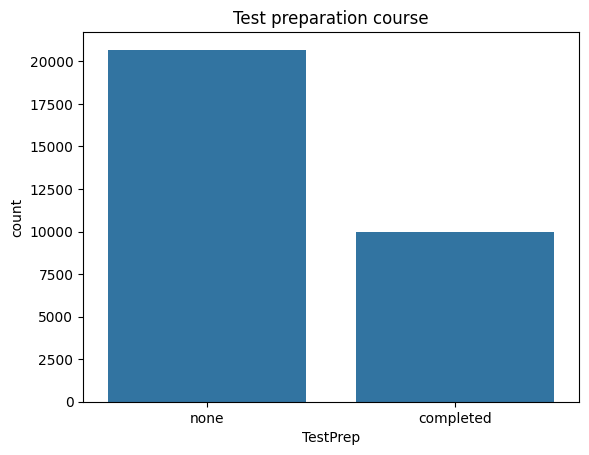

In [216]:
sns.countplot(x=data_extended['TestPrep'])
plt.title('Test preparation course');

In [217]:
display_stats(data_extended, 'TestPrep')

/tmp/ipykernel_4626/2462480265.py:14: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  .agg(np.mean).sort_values(by='MathScore', ascending=False)


,TestPrep (count),TestPrep (%)
TestPrep,,
none,20686,67.510851
completed,9955,32.489149


,MathScore,ReadingScore,WritingScore
TestPrep,,,
completed,69.546660,73.732998,74.703265
none,65.120323,67.281495,65.394180


### Analysis of Test Preparation

Most students did not complete the test preparation course, while a smaller group did.

This suggests that test preparation is not commonly used among students.

Overall, this provides a basis to examine whether completing the course leads to differences in exam performance.

### Practice sport

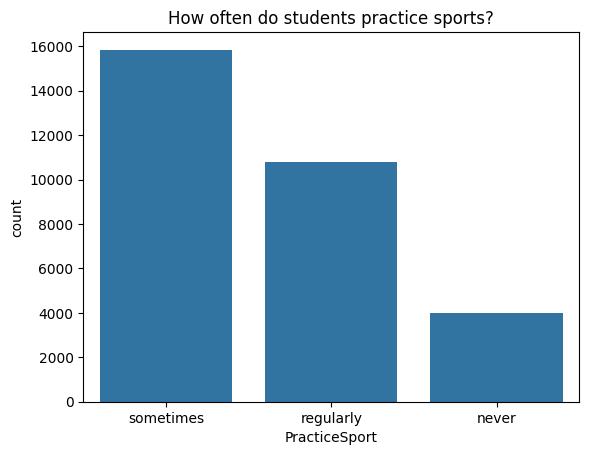

In [218]:
sns.countplot(x=data_extended['PracticeSport'], \
             order = ['sometimes', 'regularly', 'never'])
plt.title('How often do students practice sports?');

In [219]:
display_stats(data_extended, 'PracticeSport')

/tmp/ipykernel_4626/2462480265.py:14: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  .agg(np.mean).sort_values(by='MathScore', ascending=False)


,PracticeSport (count),PracticeSport (%)
PracticeSport,,
sometimes,15844,51.708495
regularly,10793,35.224046
never,4004,13.067459


,MathScore,ReadingScore,WritingScore
PracticeSport,,,
regularly,67.839155,69.943019,69.604003
sometimes,66.289258,69.255112,68.090255
never,64.171079,68.337662,66.522727


### Analysis of Practicing Sports

Most students practice sports occasionally or regularly, while a smaller group never participates.

This suggests that engaging in sports is relatively common among students.

Overall, this provides a basis to explore whether physical activity is associated with differences in academic performance.

### Parent(s) marital status
- This features seem to have little to no correlation with test scores.

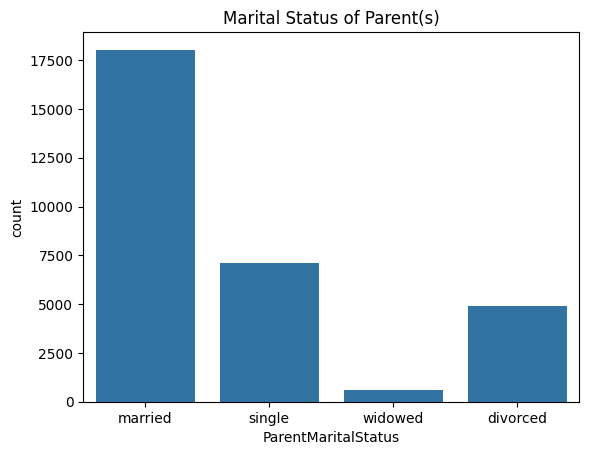

In [220]:
sns.countplot(x=data_extended['ParentMaritalStatus'])
plt.title('Marital Status of Parent(s)');

In [221]:
display_stats(data_extended, 'ParentMaritalStatus')

/tmp/ipykernel_4626/2462480265.py:14: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  .agg(np.mean).sort_values(by='MathScore', ascending=False)


,ParentMaritalStatus (count),ParentMaritalStatus (%)
ParentMaritalStatus,,
married,18034,58.855781
single,7097,23.161777
divorced,4919,16.053654
widowed,591,1.928788


,MathScore,ReadingScore,WritingScore
ParentMaritalStatus,,,
widowed,67.368866,69.651438,68.563452
divorced,66.691197,69.655011,68.799146
married,66.650161,69.379561,68.406177
single,66.165704,69.157250,68.174440


### Analysis of Parental Marital Status

Most students come from married families, while fewer come from single, divorced, or widowed backgrounds.

This suggests that the dataset is dominated by students with married parents.

Overall, this provides a basis to explore whether family structure is associated with differences in academic performance.

### Is the student the first child in the family?

- About 65% of the students are first child in their family.
- Scores are independent of this feature alone; changes are within < 0.5% in all the three test subjects.


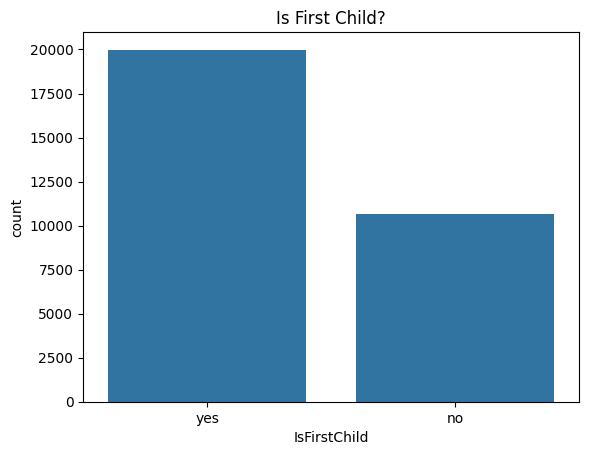

In [222]:
sns.countplot(x=data_extended['IsFirstChild'])
plt.title('Is First Child?');

In [223]:
display_stats(data_extended, 'IsFirstChild')

/tmp/ipykernel_4626/2462480265.py:14: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  .agg(np.mean).sort_values(by='MathScore', ascending=False)


,IsFirstChild (count),IsFirstChild (%)
IsFirstChild,,
yes,19986,65.226331
no,10655,34.773669


,MathScore,ReadingScore,WritingScore
IsFirstChild,,,
yes,66.724507,69.508106,68.529371
no,66.246832,69.132614,68.210887


### Analysis of First Child Status

Most students are first children, while a smaller portion are not.

This suggests that the dataset is slightly skewed toward first-born students.

Overall, this provides a basis to examine whether birth order is associated with differences in academic performance.

### Number of siblings the student has

This feature has little to no effect on score. On writing and reading tests there is only just over 1 point difference and on math test about 1.7 points between two groups of students i.e, students with 7 siblings coming on top while students with 6 students coming at the bottom of the rank. Doubt this makes a lot of sense.


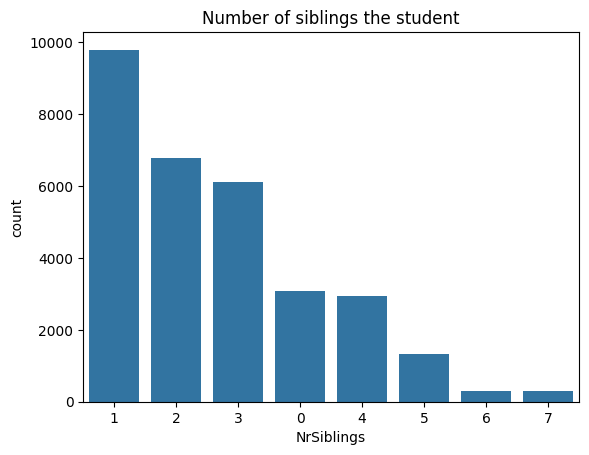

In [224]:
sns.countplot(x=data_extended['NrSiblings'],
             order=[1, 2, 3, 0, 4, 5, 6, 7]
             )
plt.title('Number of siblings the student');

In [225]:
display_stats(data_extended, 'NrSiblings')

/tmp/ipykernel_4626/2462480265.py:14: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  .agg(np.mean).sort_values(by='MathScore', ascending=False)


,NrSiblings (count),NrSiblings (%)
NrSiblings,,
1,9789,31.947391
2,6790,22.159851
3,6123,19.983029
0,3085,10.068209
4,2941,9.598251
5,1320,4.307953
6,302,0.985608
7,291,0.949708


,MathScore,ReadingScore,WritingScore
NrSiblings,,,
7,67.615120,69.828179,68.986254
0,66.819449,69.547812,68.746515
3,66.719092,69.488159,68.650498
5,66.630303,69.453788,68.282576
2,66.554934,69.472018,68.522533
1,66.450710,69.253346,68.220554
4,66.245495,69.144169,68.073444
6,65.917219,68.801325,67.860927


### Analysis of Number of Siblings

Most students have 1 to 3 siblings, while higher numbers of siblings are less common.

This suggests that the dataset is concentrated around smaller family sizes.

Overall, this provides a basis to explore whether family size is associated with differences in academic performance.

### Means of transport to school
- No effect on the test scores.

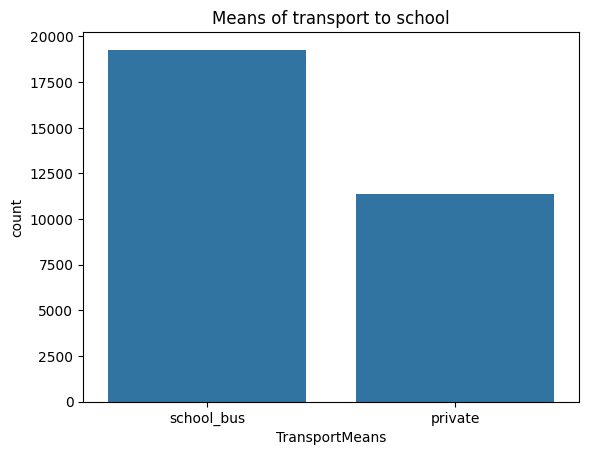

In [226]:
sns.countplot(x=data_extended['TransportMeans'])
plt.title('Means of transport to school');

In [227]:
display_stats(data_extended, 'TransportMeans')

/tmp/ipykernel_4626/2462480265.py:14: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  .agg(np.mean).sort_values(by='MathScore', ascending=False)


,TransportMeans (count),TransportMeans (%)
TransportMeans,,
school_bus,19279,62.918965
private,11362,37.081035


,MathScore,ReadingScore,WritingScore
TransportMeans,,,
school_bus,66.586130,69.321645,68.365009
private,66.511354,69.472364,68.509593


### Analysis of Transportation to School

Most students use the school bus, while a smaller portion use private transportation.

This suggests that school-provided transport is the more common option.

Overall, this provides a basis to explore whether transportation type is associated with differences in academic performance.

### Interacting features

In the above section we have seen the distribution and effect of individual features on test scores. While some of the features such as lunch type and test preparation course have considerable effect, some other features on the other hand have little to no effect at all. But it is advisable to check the interacting effect with other features before we discard/neglect these features altogether before we make our final conclusions on their usefulness. In the section below, without commenting on specific figures, I gave a few examples of interacting features. I invite the reader to explore further and maybe discover some insights on which interacting features have the most/least importance to make useful conclusions.


In [228]:
data_extended.groupby(['Gender', 'ParentEduc'])[
    ['MathScore', 'ReadingScore', 'WritingScore']
].agg(np.mean)

/tmp/ipykernel_4626/2032609867.py:3: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  ].agg(np.mean)


MathScore  ReadingScore  WritingScore
Gender ParentEduc                                               
female associate's degree  65.994933     74.759682     74.913500
       bachelor's degree   67.498233     75.981154     77.217314
       high school         62.194580     70.958652     70.155664
       master's degree     70.181195     79.376102     80.804114
       some college        63.745936     72.491640     72.662796
       some high school    60.291153     69.144307     68.289340
male   associate's degree  70.715823     67.520273     65.724435
       bachelor's degree   73.452607     70.125592     69.421801
       high school         66.731933     63.377358     60.570310
       master's degree     74.531936     72.222555     71.825349
       some college        69.232742     65.781640     64.115532
       some high school    64.876042     61.878579     58.977166

In [229]:
data_extended.groupby(['EthnicGroup', 'Gender'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)


/tmp/ipykernel_4626/294726912.py:1: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data_extended.groupby(['EthnicGroup', 'Gender'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)


MathScore  ReadingScore  WritingScore
EthnicGroup Gender                                       
group A     female  60.696349     70.438112     69.913624
            male    65.343978     63.047445     60.475365
group B     female  61.030754     70.824265     70.312268
            male    66.028601     63.704220     61.336240
group C     female  62.405381     71.922174     71.564644
            male    67.493290     65.098477     62.714726
group D     female  65.227707     74.033439     75.436306
            male    70.126640     66.698795     66.305221
group E     female  72.813851     77.482318     76.916503
            male    77.822444     70.970574     68.372070

In [230]:
data_extended.groupby(['EthnicGroup', 'LunchType'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)


/tmp/ipykernel_4626/2594342263.py:1: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data_extended.groupby(['EthnicGroup', 'LunchType'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)


MathScore  ReadingScore  WritingScore
EthnicGroup LunchType                                          
group A     free/reduced  54.952507     61.150396     58.804749
            standard      67.162902     69.712526     68.596851
group B     free/reduced  55.577735     61.897793     59.912188
            standard      67.896847     70.340460     69.227151
group C     free/reduced  57.238950     63.309412     61.372075
            standard      69.056064     71.297530     70.232723
group D     free/reduced  59.662973     65.046236     64.978219
            standard      71.953131     73.240278     74.057716
group E     free/reduced  68.615653     69.937107     67.854647
            standard      78.963218     76.616858     75.321073

In [231]:
data_extended.groupby(['PracticeSport', 'TestPrep'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)

/tmp/ipykernel_4626/673979319.py:1: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data_extended.groupby(['PracticeSport', 'TestPrep'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)


MathScore  ReadingScore  WritingScore
PracticeSport TestPrep                                        
never         completed  67.375678     73.056545     73.012393
              none       62.646148     66.092149     63.434574
regularly     completed  70.844084     74.345965     76.008100
              none       66.423119     67.868184     66.586150
sometimes     completed  69.223545     73.493758     74.256194
              none       64.852872     67.180220     65.071919

In [232]:
data_extended.groupby(['PracticeSport', 'WklyStudyHours'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)

/tmp/ipykernel_4626/2771690970.py:1: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data_extended.groupby(['PracticeSport', 'WklyStudyHours'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)


MathScore  ReadingScore  WritingScore
PracticeSport WklyStudyHours                                       
never         5 - 10          64.663572     68.908930     67.112732
              < 5             62.071225     67.112061     64.949668
              > 10            65.763425     68.335269     66.989840
regularly     5 - 10          68.156546     70.250374     69.744635
              < 5             65.616172     68.587854     68.426476
              > 10            70.328471     71.090762     71.011885
sometimes     5 - 10          66.541779     69.441532     68.290547
              < 5             64.487776     68.155853     66.699342
              > 10            68.321187     70.386551     69.641247

In [233]:
data_extended.groupby(['Gender', 'PracticeSport'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)

/tmp/ipykernel_4626/476682240.py:1: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data_extended.groupby(['Gender', 'PracticeSport'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)


MathScore  ReadingScore  WritingScore
Gender PracticeSport                                       
female never          61.979208     71.805941     70.983663
       regularly      65.297035     73.428624     73.994510
       sometimes      63.778212     72.723678     72.549748
male   never          66.402722     64.806452     61.980847
       regularly      70.445675     66.369112     65.102271
       sometimes      68.811741     65.770749     63.610450

In [234]:
data_extended.groupby(['Gender', 'PracticeSport'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)

/tmp/ipykernel_4626/476682240.py:1: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data_extended.groupby(['Gender', 'PracticeSport'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)


MathScore  ReadingScore  WritingScore
Gender PracticeSport                                       
female never          61.979208     71.805941     70.983663
       regularly      65.297035     73.428624     73.994510
       sometimes      63.778212     72.723678     72.549748
male   never          66.402722     64.806452     61.980847
       regularly      70.445675     66.369112     65.102271
       sometimes      68.811741     65.770749     63.610450

In [235]:
data_extended.groupby(['IsFirstChild', 'Gender', 'NrSiblings'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)

/tmp/ipykernel_4626/3336912435.py:1: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data_extended.groupby(['IsFirstChild', 'Gender', 'NrSiblings'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)


MathScore  ReadingScore  WritingScore
IsFirstChild Gender NrSiblings                                       
no           female 1           64.017116     72.844917     72.712656
                    2           63.563663     72.115413     72.250931
                    3           64.409928     73.101681     73.169736
                    4           63.760000     72.765455     72.887273
                    5           61.757447     70.497872     70.638298
                    6           59.297872     67.319149     67.148936
                    7           63.269231     72.365385     72.442308
             male   1           68.448257     65.514665     63.532374
                    2           69.264179     66.280597     64.347761
                    3           68.769164     65.371951     63.591463
                    4           67.678571     64.377551     62.409864
                    5           70.174242     66.522727     65.056818
                    6           69.346154     65.480769     63.923077
                    7           69.019231     65.846154     64.153846
yes          female 0           64.361415     73.097106     73.243730
                    1           63.777740     72.575101     72.555480
                    2           64.346099     73.389181     73.310196
                    3           64.640337     73.039494     73.128489
                    4           63.932967     73.057143     72.942857
                    5           64.454545     73.421053     73.031100
                    6           66.392523     74.813084     74.869159
                    7           63.697674     71.930233     72.267442
             male   0           69.317647     65.940523     64.175817
                    1           69.350549     66.029374     64.023241
                    2           69.033201     65.777007     63.857284
                    3           69.170224     65.912972     64.085386
                    4           69.189250     66.064950     63.875700
                    5           69.406948     66.650124     64.096774
                    6           66.770833     64.625000     62.531250
                    7           72.465347     68.782178     66.900990

In [236]:
data_extended.groupby(['PracticeSport', 'WklyStudyHours', 'ParentEduc'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)

/tmp/ipykernel_4626/593250450.py:1: FutureWarning: The provided callable <function mean at 0x7929901f9940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  data_extended.groupby(['PracticeSport', 'WklyStudyHours', 'ParentEduc'])[['MathScore', 'ReadingScore', 'WritingScore']].agg(np.mean)


MathScore  ReadingScore  \
PracticeSport WklyStudyHours ParentEduc                                    
never         5 - 10         associate's degree  66.267303     70.200477   
                             bachelor's degree   70.401674     73.205021   
                             high school         62.274232     66.262411   
                             master's degree     70.832298     75.801242   
                             some college        64.202875     68.971246   
                             some high school    60.253807     64.855330   
              < 5            associate's degree  64.648045     69.798883   
                             bachelor's degree   68.087719     71.578947   
                             high school         58.849162     63.983240   
                             master's degree     68.023256     73.686047   
                             some college        61.770764     66.813953   
                             some high school    56.958763     62.443299   
              > 10           associate's degree  68.661654     71.285714   
                             bachelor's degree   68.924242     70.712121   
                             high school         64.467153     67.751825   
                             master's degree     72.285714     75.306122   
                             some college        64.037433     66.786096   
                             some high school    62.230769     63.880342   
regularly     5 - 10         associate's degree  69.964121     71.989880   
                             bachelor's degree   71.692878     73.565282   
                             high school         66.245009     68.539020   
                             master's degree     73.569444     76.336111   
                             some college        68.340000     70.275294   
                             some high school    64.018382     66.139706   
              < 5            associate's degree  66.652174     69.828063   
                             bachelor's degree   68.912913     71.738739   
                             high school         64.207510     67.084980   
                             master's degree     71.734597     75.341232   
                             some college        65.346244     68.028169   
                             some high school    61.848948     65.022945   
              > 10           associate's degree  72.764706     73.879412   
                             bachelor's degree   74.382775     75.397129   
                             high school         67.993485     69.345277   
                             master's degree     76.666667     76.268293   
                             some college        70.347656     70.531250   
                             some high school    65.472222     66.472222   
sometimes     5 - 10         associate's degree  68.106707     70.837195   
                             bachelor's degree   70.085513     72.941650   
                             high school         64.252716     66.921098   
                             master's degree     72.914855     76.860507   
                             some college        66.650696     69.458231   
                             some high school    62.757576     65.898130   
              < 5            associate's degree  66.515504     69.992248   
                             bachelor's degree   68.178947     72.197895   
                             high school         62.620907     65.789673   
                             master's degree     69.951890     73.797251   
                             some college        64.062555     67.895154   
                             some high school    60.732484     64.578344   
              > 10           associate's degree  70.474576     72.667373   
                             bachelor's degree   73.042553     74.599291   
                             high school         65.865306     68.236735   
                     

In [237]:
data_extended['ExamScore'] = data_extended[['MathScore', 'ReadingScore', 'WritingScore']].mean(axis=1)

from scipy.stats import ttest_ind

completed = data_extended[data_extended['TestPrep'] == 'completed']['ExamScore']
none = data_extended[data_extended['TestPrep'] == 'none']['ExamScore']

t_stat, p_value = ttest_ind(completed, none)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 39.10454697491864
P-value: 0.0


The very small p-value indicates a statistically significant difference between the groups.

In [238]:
data_extended.groupby('TestPrep')['ExamScore'].mean()

,ExamScore
TestPrep,
completed,72.660974
none,65.931999


### Hypothesis Test: Effect of Test Preparation

A t-test was conducted to compare the exam scores of students who completed the test preparation course and those who did not.

The results show a very high t-statistic (39.10) and a p-value close to 0, indicating a statistically significant difference between the two groups.

Additionally, the average exam score for students who completed the course (72.66) is noticeably higher than for those who did not (65.93).

This suggests that test preparation is strongly associated with improved academic performance.

In [239]:
from scipy.stats import f_oneway

group1 = data_extended[data_extended['WklyStudyHours'] == '< 5']['ExamScore']
group2 = data_extended[data_extended['WklyStudyHours'] == '5 - 10']['ExamScore']
group3 = data_extended[data_extended['WklyStudyHours'] == '> 10']['ExamScore']

f_stat, p_value = f_oneway(group1, group2, group3)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 75.65459897769917
P-value: 1.6768392972274355e-33


In [240]:
data_extended.groupby('WklyStudyHours')['ExamScore'].mean()

,ExamScore
WklyStudyHours,
5 - 10,68.385675
< 5,66.615562
> 10,69.613290


In [241]:
data_extended.groupby('WklyStudyHours')['ExamScore'].mean().sort_index()

,ExamScore
WklyStudyHours,
5 - 10,68.385675
< 5,66.615562
> 10,69.613290


### Hypothesis Test: Effect of Weekly Study Hours

A one-way ANOVA test was conducted to examine whether weekly study hours have an effect on students' exam scores.

The results show a high F-statistic (75.65) and a p-value close to 0, indicating that there is a statistically significant difference between the groups.

This means that students who study different amounts of time per week tend to have different levels of academic performance.

Overall, this suggests that study time is an important factor influencing exam scores.

Additionally, the mean exam scores increase as study hours increase, reinforcing the conclusion that there is a positive relationship between study time and academic performance.


# Final Conclusion

This analysis explored various factors affecting students’ academic performance.

Among all variables, test preparation and weekly study hours showed the strongest relationship with exam scores.

Students who completed the test preparation course and those who studied more hours per week consistently achieved higher scores.

While other factors such as gender, parental education, and lunch type showed some variation, their effects were less pronounced.

Overall, the findings suggest that individual effort
and preparation play a key role in academic success.